## 1.Load dataset and inspect features and labels distribution.


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [15]:
cancer = load_breast_cancer()

In [16]:
x = cancer.data #feature 
y = cancer.target

## 2.Split data into train-test sets.


In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

array([[9.029e+00, 1.733e+01, 5.879e+01, ..., 1.750e-01, 4.228e-01,
        1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, ..., 2.903e-01, 4.098e-01,
        1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, ..., 5.087e-02, 3.282e-01,
        8.490e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]])

## 3.Apply StandardScaler to normalize feature values.


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

## 4.Train baseline SVM with linear kernel and check performance.


In [23]:
from sklearn.svm import SVC

In [25]:
model = SVC(kernel='linear',random_state=42)

In [26]:
model.fit(x_train_scaler,y_train)

SVC(kernel='linear', random_state=42)

In [27]:
prediction = model.predict(x_test_scaler)

In [28]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [34]:
print(f"Accuracy: {accuracy_score(y_test,prediction)*100}")

Accuracy: 95.6140350877193


In [37]:
print(f"Classification report: \n{classification_report(y_test,prediction)}")

Classification report: 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [41]:
print(f'Confusioon Matrix: \n{confusion_matrix(y_test,prediction)}')

Confusioon Matrix: 
[[41  2]
 [ 3 68]]


## 5.Train SVM with RBF kernel and compare accuracy.


In [42]:
model_rbf = SVC(kernel='rbf',random_state=42)

In [43]:
model_rbf.fit(x_train_scaler,y_train)

SVC(random_state=42)

In [44]:
prediction_y = model_rbf.predict(x_test_scaler)

In [45]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [49]:
print(f"Accuracy Score: {accuracy_score(y_test,prediction_y)*100}")

Accuracy Score: 98.24561403508771


In [51]:
print(f"Classification Report: \n{classification_report(y_test,prediction_y)}")

Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [52]:
print(f"Confusion Matrix: \n{confusion_matrix(y_test,prediction_y)}")

Confusion Matrix: 
[[41  2]
 [ 0 71]]


## 6.Use GridSearchCV to tune C and gamma values.

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
# 1. Define the parameter grid
# C: Controls the trade-off between smooth boundary and classifying training points correctly.
# Gamma: Defines how far the influence of a single training example reaches
param_grid = {
    'C':[0.1,1,10,100],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']
}


In [55]:
# 2. Initialize GridSearchCV
# refit=True ensures the best model is retrained on the entire training set.
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2,cv=5)

In [56]:
#fitt the model on scaled trraining data
grid.fit(x_train_scaler,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.0

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=2)

In [58]:
# 4. Extract and view results
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Estimator: {grid.best_estimator_}")

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Estimator: SVC(C=100, gamma=0.001)


## 7.Evaluate best model using confusion matrix and classification report.


In [59]:
#5. Evaluate on the test data
grid_predictioin_y = grid.predict(x_test_scaler)

In [60]:
print(f"Accuracy Score: {accuracy_score(y_test,grid_predictioin_y)*100}")

Accuracy Score: 98.24561403508771


In [61]:
print(f"Classification Report:\n{classification_report(y_test,grid_predictioin_y)}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [64]:
print(f"Confusion Matrix:\n{confusion_matrix(y_test,grid_predictioin_y)}")

Confusion Matrix:
[[41  2]
 [ 0 71]]


In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<Figure size 1600x1000 with 0 Axes>

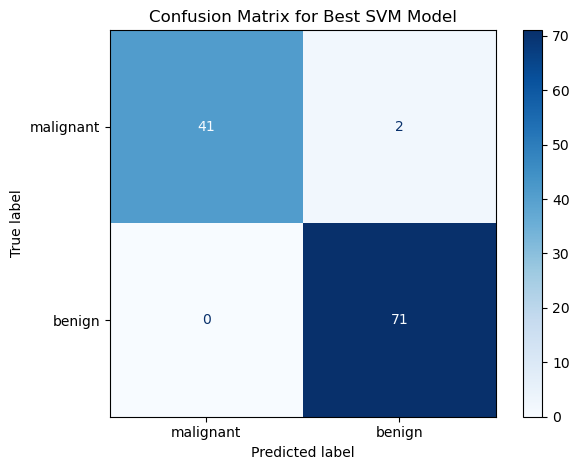

In [77]:
# Visualize using scikit-learn's built-in tool
cm = confusion_matrix(y_test,grid_predictioin_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
plt.figure(figsize=(16,10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Best SVM Model")
plt.tight_layout()
plt.show()


Best Model ROC-AUC Score: 0.9767


<Figure size 1500x800 with 0 Axes>

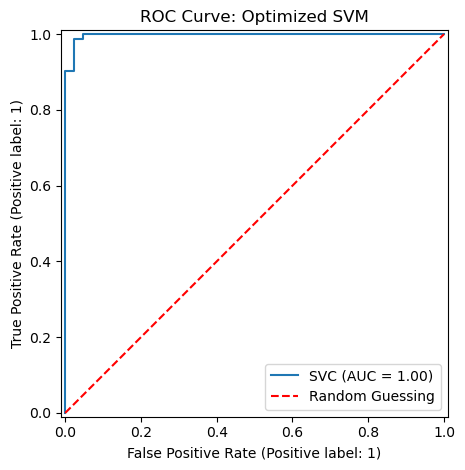

In [86]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
#plt.figure(figsize=(15,8))
# 1. Calculate the AUC score
# For SVM, decision_function is typically used for the score
y_scores = grid.decision_function(x_test_scaler)
auc_score = roc_auc_score(y_test, prediction_y)

print(f"Best Model ROC-AUC Score: {auc_score:.4f}")
plt.figure(figsize=(15,8))
# 2. Plot the ROC Curve
RocCurveDisplay.from_estimator(grid.best_estimator_, x_test_scaler, y_test)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing') # Baseline
plt.title("ROC Curve: Optimized SVM")
plt.legend()
plt.tight_layout()
plt.show()


## 9.Save tuned model pipeline (scaler + svm) for reuse.


In [88]:
import joblib
from sklearn.pipeline import Pipeline

# Create the final pipeline using the best estimator from your GridSearchCV
final_pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', grid.best_estimator_)
])

# Save the entire pipeline to a file
# Compression (compress=3) helps reduce the file size on disk
joblib.dump(final_pipeline, 'breast_cancer_svm_pipeline.joblib', compress=3)
print("Pipeline saved successfully!")


Pipeline saved successfully!
